# Support & Resistance Analysis — Bybit (Local Cache)

رسم خطوط حمایت و مقاومت قوی برای همه تایم‌فریم‌ها از داده‌های کَش شده.

| رنگ | معنا |
|-----|------|
| قرمز کم‌رنگ خط‌چین | مقاومت معمولی (۲+ برخورد) |
| قرمز پررنگ | مقاومت قوی (۳+ برخورد) |
| قرمز تیره ضخیم | مقاومت خیلی قوی (۵+ برخورد) |
| سبز کم‌رنگ خط‌چین | حمایت معمولی (۲+ برخورد) |
| سبز پررنگ | حمایت قوی (۳+ برخورد) |
| سبز تیره ضخیم | حمایت خیلی قوی (۵+ برخورد) |
| نارنجی (فقط M5) | مقاومت H1 روی چارت M5 |
| آبی فیروزه‌ای (فقط M5) | حمایت H1 روی چارت M5 |

In [11]:
# SECTION 1 — Imports & Parameters
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

plt.style.use("seaborn-v0_8-darkgrid")

_ROOT = Path.cwd().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

_TEHRAN = "Asia/Tehran"
DATA_DIR = _ROOT / "notebooks" / "data"

# ── User parameters ──────────────────────────────────────
SYMBOL = "ETHUSDT"   # ETHUSDT | SOLUSDT | BNBUSDT | ADAUSDT | ...

# bars to load from CSV per timeframe
BARS_LOAD = {"M5": 1500, "M15": 800, "M30": 500, "H1": 400, "H4": 200, "D1": 200}

# how many recent bars to display in each chart
BARS_SHOW = {"M5": 300, "M15": 250, "M30": 200, "H1": 200, "H4": 150, "D1": 100}

# pivot detection window (bars on each side)
SR_WINDOW     = {"M5": 3, "M15": 4, "M30": 4, "H1": 5, "H4": 5,  "D1": 6}

# clustering tolerance as fraction of average price
SR_TOLERANCE  = {"M5": 0.0010, "M15": 0.0012, "M30": 0.0015,
                 "H1": 0.0020, "H4":  0.0030, "D1":  0.0050}

MIN_TOUCHES         = 2   # minimum to draw a level
STRONG_TOUCHES      = 3   # classified as strong
VERY_STRONG_TOUCHES = 5   # classified as very strong

H1_OVERLAY_MIN      = 3   # min H1 touches to overlay on M5 chart

COLORS = {
    "res":            "#ef5350",   # red — regular resistance
    "res_strong":     "#b71c1c",   # dark red — very strong resistance
    "sup":            "#26a69a",   # teal — regular support
    "sup_strong":     "#004d40",   # dark teal — very strong support
    "h1_res":         "#ff9800",   # orange — H1 resistance on M5
    "h1_res_strong":  "#e65100",   # deep orange — H1 very strong resistance
    "h1_sup":         "#00bcd4",   # cyan — H1 support on M5
    "h1_sup_strong":  "#006064",   # dark cyan — H1 very strong support
}

print(f"Symbol  : {SYMBOL}")
print(f"DataDir : {DATA_DIR}")

Symbol  : ETHUSDT
DataDir : D:\bot\ema-h1trend-exchange\notebooks\data


In [12]:
# SECTION 2 — Data loading & S/R detection functions

def load_csv(symbol: str, tf: str, limit: int | None = None) -> pd.DataFrame | None:
    """Load OHLCV CSV from local cache. Returns None if file not found."""
    csv_path = DATA_DIR / symbol / tf / "ohlcv.csv"
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path, index_col=0)
    # Convert index to DatetimeIndex robustly (handles mixed/no timezone)
    df.index = pd.to_datetime(df.index, utc=True).tz_convert(_TEHRAN)
    df = df.sort_index()
    for col in ["open", "high", "low", "close", "volume"]:
        if col in df.columns:
            df[col] = df[col].astype(float)
    df = df[["open", "high", "low", "close", "volume"]]
    if limit and len(df) > limit:
        df = df.iloc[-limit:]
    return df


# ── S/R detection ────────────────────────────────────────

def _swing_highs(df: pd.DataFrame, window: int) -> list:
    pivots = []
    highs = df["high"].values
    idx   = df.index
    for i in range(window, len(df) - window):
        window_max = highs[i - window : i + window + 1].max()
        if highs[i] == window_max:
            pivots.append((idx[i], float(highs[i])))
    return pivots


def _swing_lows(df: pd.DataFrame, window: int) -> list:
    pivots = []
    lows = df["low"].values
    idx  = df.index
    for i in range(window, len(df) - window):
        window_min = lows[i - window : i + window + 1].min()
        if lows[i] == window_min:
            pivots.append((idx[i], float(lows[i])))
    return pivots


def _cluster(pivots: list, tolerance: float) -> list:
    """Merge nearby pivots into zones. Returns list of dicts."""
    if not pivots:
        return []
    prices = np.array([p[1] for p in pivots])
    times  = [p[0] for p in pivots]
    order  = np.argsort(prices)
    s_prices = prices[order]
    s_times  = [times[i] for i in order]

    used     = np.zeros(len(s_prices), dtype=bool)
    clusters = []

    for i in range(len(s_prices)):
        if used[i]:
            continue
        in_cluster = []
        for j in range(i, len(s_prices)):
            if used[j]:
                continue
            if s_prices[j] - s_prices[i] <= tolerance:
                in_cluster.append(j)
            else:
                break
        for j in in_cluster:
            used[j] = True
        cp = s_prices[in_cluster]
        ct = [s_times[j] for j in in_cluster]
        clusters.append({
            "level":       float(np.mean(cp)),
            "touches":     len(cp),
            "zone_low":    float(np.min(cp)),
            "zone_high":   float(np.max(cp)),
            "first_touch": min(ct),
            "last_touch":  max(ct),
        })
    return clusters


def get_sr_levels(
    df: pd.DataFrame,
    window: int = 5,
    tolerance_pct: float = 0.002,
    min_touches: int = 2,
) -> tuple[list, list]:
    """Return (resistance_levels, support_levels) sorted by touch count desc."""
    price_ref = float(df["close"].mean())
    tol       = price_ref * tolerance_pct

    sh = _swing_highs(df, window)
    sl = _swing_lows(df,  window)

    res = [z for z in _cluster(sh, tol) if z["touches"] >= min_touches]
    sup = [z for z in _cluster(sl, tol) if z["touches"] >= min_touches]

    res.sort(key=lambda x: x["touches"], reverse=True)
    sup.sort(key=lambda x: x["touches"], reverse=True)
    return res, sup


print("Functions loaded.")

Functions loaded.


In [13]:
# SECTION 3 — Charting functions

def _draw_candles(ax, df_plot: pd.DataFrame) -> None:
    """Draw efficient candlestick on ax. df_plot must have reset integer index."""
    n  = len(df_plot)
    xs = np.arange(n, dtype=float)

    up   = (df_plot["close"] >= df_plot["open"]).values
    down = ~up

    # wicks
    ax.vlines(xs[up],   df_plot["low"].values[up],   df_plot["high"].values[up],
              colors="#26a69a", lw=0.8, zorder=2)
    ax.vlines(xs[down], df_plot["low"].values[down], df_plot["high"].values[down],
              colors="#ef5350", lw=0.8, zorder=2)

    # bodies
    body_bot = np.minimum(df_plot["open"].values, df_plot["close"].values)
    body_h   = np.abs(df_plot["close"].values - df_plot["open"].values)
    body_h   = np.where(body_h == 0, df_plot["close"].values * 0.0001, body_h)

    ax.bar(xs[up],   body_h[up],   bottom=body_bot[up],   width=0.8,
           color="#26a69a", linewidth=0, zorder=2)
    ax.bar(xs[down], body_h[down], bottom=body_bot[down], width=0.8,
           color="#ef5350", linewidth=0, zorder=2)


def _draw_sr(
    ax, n: int,
    res_levels: list, sup_levels: list,
    price_min: float, price_max: float,
    color_res:  str, color_res_s:  str,
    color_sup:  str, color_sup_s:  str,
    label_prefix: str = "",
    label_x_left: float = 1.0,
    label_x_right: float | None = None,
    zone_alpha: float = 0.06,
    zorder_base: int = 3,
) -> list:
    """Draw S/R levels; return legend patches."""
    margin = (price_max - price_min) * 0.15
    lx = label_x_right if label_x_right is not None else n - 1

    def in_view(lv):
        return price_min - margin <= lv <= price_max + margin

    def _hline(level, color, lw, ls, alpha, label, zone_lo, zone_hi):
        ax.axhline(y=level, color=color, lw=lw, ls=ls, alpha=alpha,
                   zorder=zorder_base)
        if zone_hi > zone_lo and lw >= 1.2:
            ax.axhspan(zone_lo, zone_hi, alpha=zone_alpha, color=color,
                       zorder=zorder_base - 1)
        if label:
            ax.text(label_x_left, level, f" {label}",
                    color=color, fontsize=6.5, va="center", ha="left",
                    fontweight="bold", zorder=zorder_base + 1, clip_on=True)

    for lvl in res_levels:
        if not in_view(lvl["level"]):
            continue
        t = lvl["touches"]
        if t >= VERY_STRONG_TOUCHES:
            _hline(lvl["level"], color_res_s, 2.2, "-", 0.95,
                   f"{label_prefix}R{t}T", lvl["zone_low"], lvl["zone_high"])
        elif t >= STRONG_TOUCHES:
            _hline(lvl["level"], color_res,   1.3, "-", 0.85,
                   f"{label_prefix}R{t}T", lvl["zone_low"], lvl["zone_high"])
        else:
            _hline(lvl["level"], color_res,   0.7, "--", 0.55,
                   "",            lvl["zone_low"], lvl["zone_high"])

    for lvl in sup_levels:
        if not in_view(lvl["level"]):
            continue
        t = lvl["touches"]
        if t >= VERY_STRONG_TOUCHES:
            _hline(lvl["level"], color_sup_s, 2.2, "-", 0.95,
                   f"{label_prefix}S{t}T", lvl["zone_low"], lvl["zone_high"])
        elif t >= STRONG_TOUCHES:
            _hline(lvl["level"], color_sup,   1.3, "-", 0.85,
                   f"{label_prefix}S{t}T", lvl["zone_low"], lvl["zone_high"])
        else:
            _hline(lvl["level"], color_sup,   0.7, "--", 0.55,
                   "",            lvl["zone_low"], lvl["zone_high"])

    pfx = label_prefix.strip() + " " if label_prefix.strip() else ""
    patches = [
        mpatches.Patch(color=color_res,   label=f"{pfx}Resistance  (2+ touches)"),
        mpatches.Patch(color=color_res_s, label=f"{pfx}Resistance  ({VERY_STRONG_TOUCHES}+ touches)"),
        mpatches.Patch(color=color_sup,   label=f"{pfx}Support     (2+ touches)"),
        mpatches.Patch(color=color_sup_s, label=f"{pfx}Support     ({VERY_STRONG_TOUCHES}+ touches)"),
    ]
    return patches


def plot_sr_chart(
    df: pd.DataFrame,
    tf: str,
    res_levels: list,
    sup_levels: list,
    h1_res: list | None = None,
    h1_sup: list | None = None,
    show_n_bars: int = 200,
    figsize: tuple = (18, 7),
) -> None:
    """Plot candlestick + S/R levels. h1_res/h1_sup overlaid in orange/cyan."""
    df_plot = df.iloc[-show_n_bars:].reset_index()
    n = len(df_plot)

    fig, ax = plt.subplots(figsize=figsize)
    _draw_candles(ax, df_plot)

    price_min = float(df_plot["low"].min())
    price_max = float(df_plot["high"].max())

    legend_patches = []

    # H1 overlay (drawn first → behind own-TF lines)
    if h1_res is not None or h1_sup is not None:
        h1r = h1_res or []
        h1s = h1_sup or []
        p = _draw_sr(
            ax, n, h1r, h1s, price_min, price_max,
            color_res=COLORS["h1_res"],  color_res_s=COLORS["h1_res_strong"],
            color_sup=COLORS["h1_sup"],  color_sup_s=COLORS["h1_sup_strong"],
            label_prefix="H1-",
            label_x_left=n * 0.65,
            zone_alpha=0.07,
            zorder_base=3,
        )
        legend_patches.extend(p)

    # Own-TF S/R (drawn on top)
    p2 = _draw_sr(
        ax, n, res_levels, sup_levels, price_min, price_max,
        color_res=COLORS["res"],  color_res_s=COLORS["res_strong"],
        color_sup=COLORS["sup"],  color_sup_s=COLORS["sup_strong"],
        label_prefix="",
        label_x_left=1.0,
        zone_alpha=0.06,
        zorder_base=5,
    )
    legend_patches.extend(p2)

    # x-axis ticks
    step = max(1, n // 10)
    tick_xs     = list(range(0, n, step))
    tick_labels = []
    for i in tick_xs:
        t = df_plot.iloc[i]["time"]
        if hasattr(t, "tz_convert"):
            t = t.tz_convert(_TEHRAN)
        tick_labels.append(t.strftime("%m-%d\n%H:%M"))
    ax.set_xticks(tick_xs)
    ax.set_xticklabels(tick_labels, fontsize=7)
    ax.set_xlim(-1, n + 18)

    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4g"))
    ax.legend(handles=legend_patches, loc="upper left",
              fontsize=7, ncol=2, framealpha=0.85)

    last = float(df_plot["close"].iloc[-1])
    h1_note = " (+H1 overlay)" if (h1_res or h1_sup) else ""
    ax.set_title(f"{SYMBOL} | {tf}{h1_note} | Last: {last:.6g} | Support & Resistance",
                 fontsize=11)
    ax.set_ylabel("Price")
    plt.tight_layout()
    plt.show()


print("Chart functions loaded.")

Chart functions loaded.


In [14]:
# SECTION 4 — Check available timeframes
ALL_TFS = ["M5", "M15", "M30", "H1", "H4", "D1"]

print(f"Checking data for {SYMBOL}...")
available_tfs = []
for tf in ALL_TFS:
    p = DATA_DIR / SYMBOL / tf / "ohlcv.csv"
    if p.exists():
        size = p.stat().st_size // 1024
        print(f"  ✓  {tf:<5}  {size:>5} KB")
        available_tfs.append(tf)
    else:
        print(f"  ✗  {tf:<5}  (not found)")

print(f"\nAvailable TFs: {available_tfs}")

Checking data for ETHUSDT...
  ✓  M5      6466 KB
  ✓  M15      325 KB
  ✓  M30      327 KB
  ✓  H1       559 KB
  ✓  H4       331 KB
  ✓  D1       125 KB

Available TFs: ['M5', 'M15', 'M30', 'H1', 'H4', 'D1']


In [15]:
# SECTION 5 — Load data & compute S/R levels for all TFs
data   = {}   # tf -> DataFrame
sr     = {}   # tf -> (res_levels, sup_levels)

for tf in available_tfs:
    limit = BARS_LOAD.get(tf, 400)
    df = load_csv(SYMBOL, tf, limit=limit)
    if df is None or df.empty:
        print(f"  {tf}: no data")
        continue
    data[tf] = df

    window  = SR_WINDOW.get(tf, 5)
    tol_pct = SR_TOLERANCE.get(tf, 0.002)
    res, sup = get_sr_levels(df, window=window,
                             tolerance_pct=tol_pct,
                             min_touches=MIN_TOUCHES)
    sr[tf] = (res, sup)

    strong_res = sum(1 for z in res if z["touches"] >= STRONG_TOUCHES)
    strong_sup = sum(1 for z in sup if z["touches"] >= STRONG_TOUCHES)
    print(f"  {tf:<5}  rows={len(df):>5}  "
          f"res={len(res):>3} (strong={strong_res})  "
          f"sup={len(sup):>3} (strong={strong_sup})")

print("\nDone.")

  M5     rows= 1500  res= 25 (strong=23)  sup= 29 (strong=20)
  M15    rows=  800  res= 20 (strong=7)  sup= 17 (strong=11)
  M30    rows=  500  res= 13 (strong=5)  sup= 12 (strong=7)
  H1     rows=  400  res=  7 (strong=2)  sup= 10 (strong=3)
  H4     rows=  200  res=  5 (strong=1)  sup=  5 (strong=2)
  D1     rows=  200  res=  0 (strong=0)  sup=  0 (strong=0)

Done.


In [16]:
# SECTION 6 — S/R Level Summary Table

rows = []
for tf, (res, sup) in sr.items():
    for lvl in res:
        rows.append({"tf": tf, "type": "RES",
                     "level": round(lvl["level"], 6),
                     "touches": lvl["touches"],
                     "zone_low": round(lvl["zone_low"], 6),
                     "zone_high": round(lvl["zone_high"], 6),
                     "strength": "★★★" if lvl["touches"] >= VERY_STRONG_TOUCHES
                                 else "★★" if lvl["touches"] >= STRONG_TOUCHES
                                 else "★"})
    for lvl in sup:
        rows.append({"tf": tf, "type": "SUP",
                     "level": round(lvl["level"], 6),
                     "touches": lvl["touches"],
                     "zone_low": round(lvl["zone_low"], 6),
                     "zone_high": round(lvl["zone_high"], 6),
                     "strength": "★★★" if lvl["touches"] >= VERY_STRONG_TOUCHES
                                 else "★★" if lvl["touches"] >= STRONG_TOUCHES
                                 else "★"})

summary_df = pd.DataFrame(rows)
if not summary_df.empty:
    # show only strong+ levels
    strong_df = summary_df[summary_df["touches"] >= STRONG_TOUCHES].copy()
    strong_df = strong_df.sort_values(["tf", "touches"], ascending=[True, False])
    print(f"Strong levels ({STRONG_TOUCHES}+ touches):")
    display(strong_df.reset_index(drop=True))
else:
    print("No levels found.")

Strong levels (3+ touches):


,tf,type,level,touches,zone_low,zone_high,strength
0,H1,RES,2323.315000,4,2320.80,2325.00,★★
1,H1,RES,2345.255000,4,2343.49,2346.75,★★
2,H1,SUP,2265.982500,4,2263.77,2268.31,★★
3,H1,SUP,2277.956667,3,2277.77,2278.23,★★
4,H1,SUP,2308.936667,3,2307.15,2311.11,★★
...,...,...,...,...,...,...,...
76,M5,SUP,2272.770000,3,2272.02,2273.47,★★
77,M5,SUP,2276.933333,3,2275.67,2277.74,★★
78,M5,SUP,2294.856667,3,2294.08,2295.69,★★
79,M5,SUP,2316.886667,3,2316.20,2317.63,★★


---
## Charts — All Timeframes

یک چارت جداگانه برای هر تایم‌فریم با خطوط حمایت و مقاومت


── M5 ── res=25 sup=29 (showing last 300 bars)


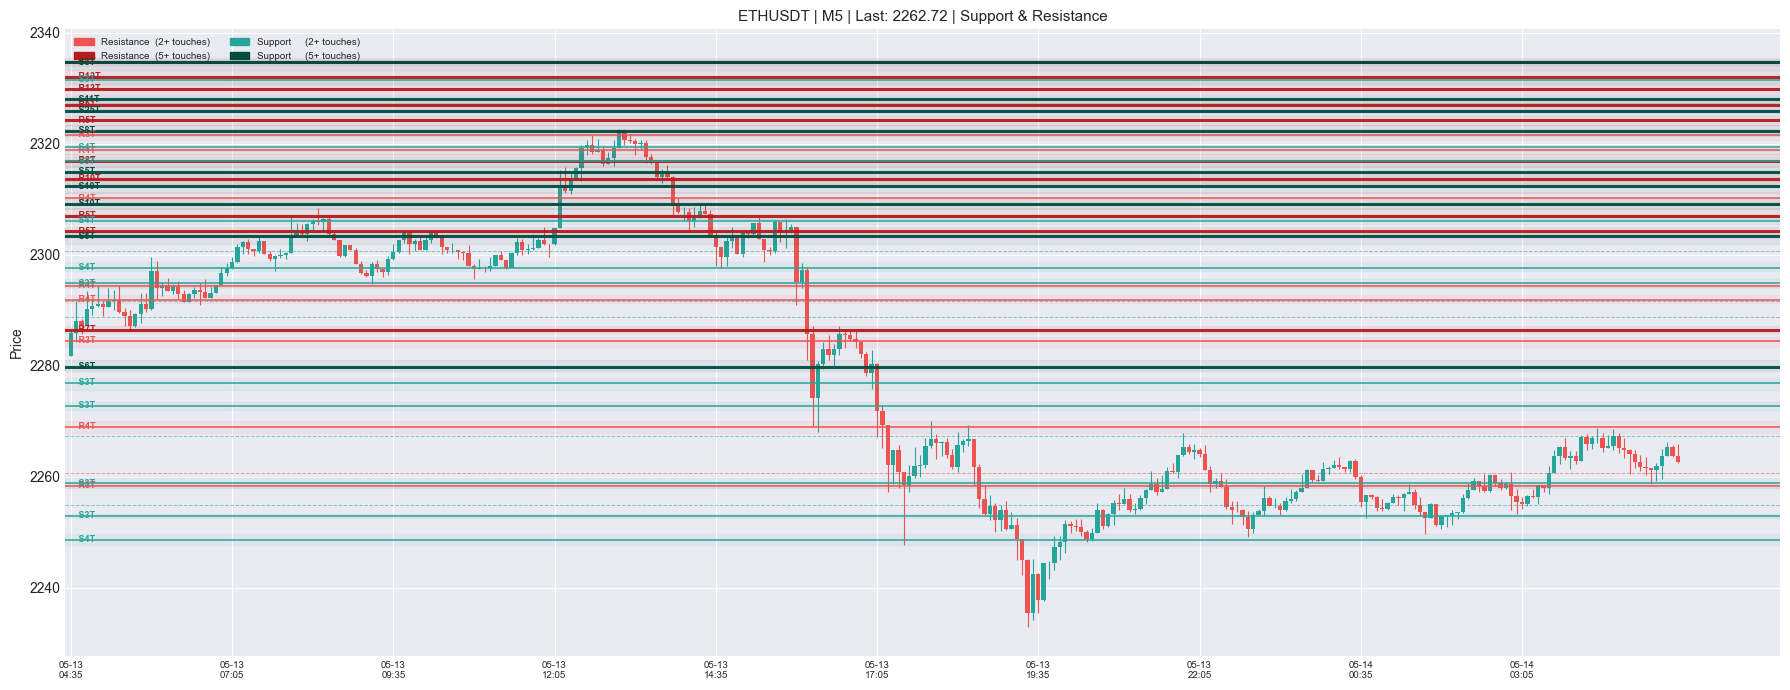


── M15 ── res=20 sup=17 (showing last 250 bars)


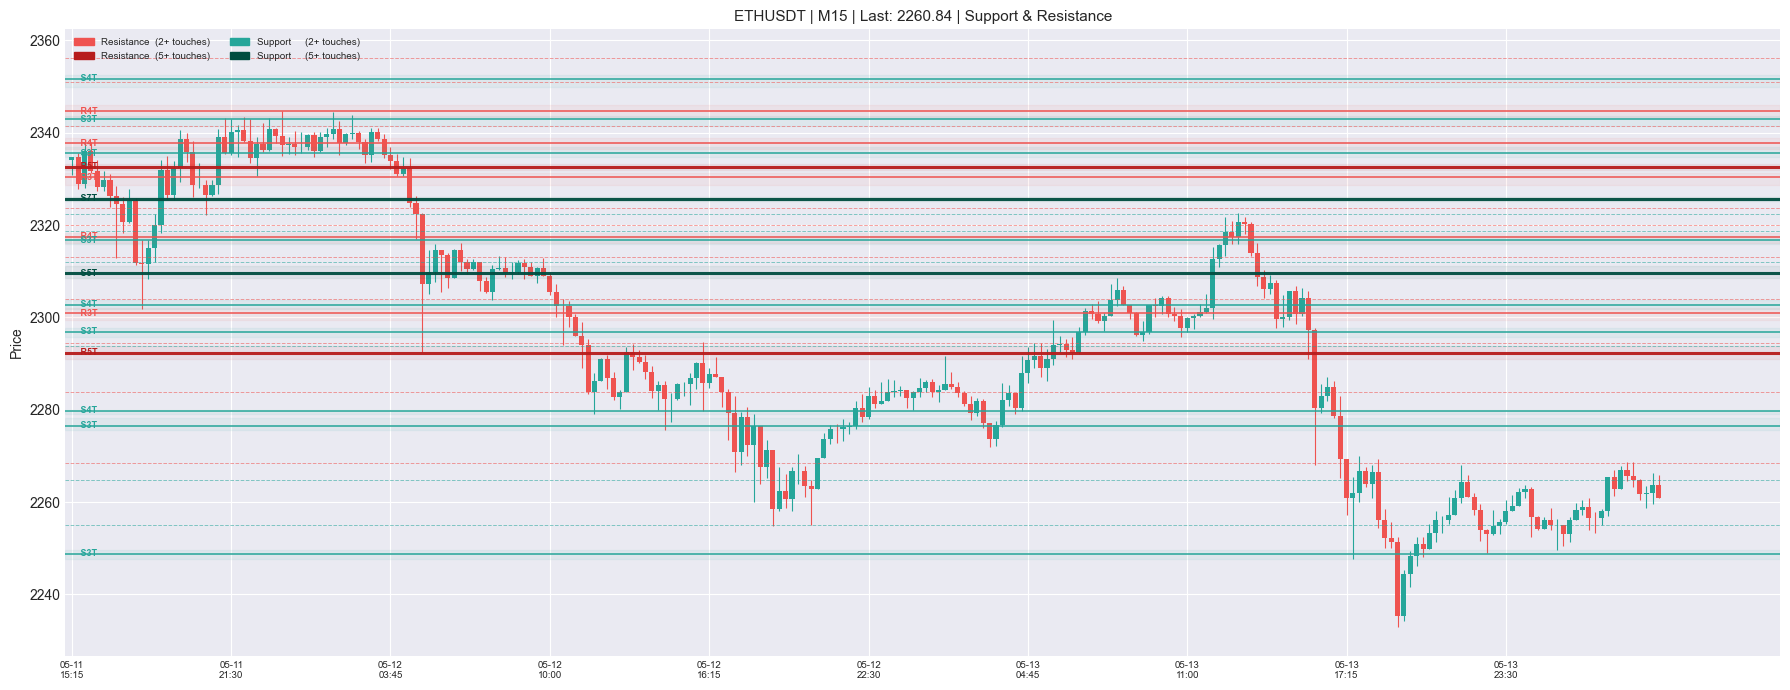


── M30 ── res=13 sup=12 (showing last 200 bars)


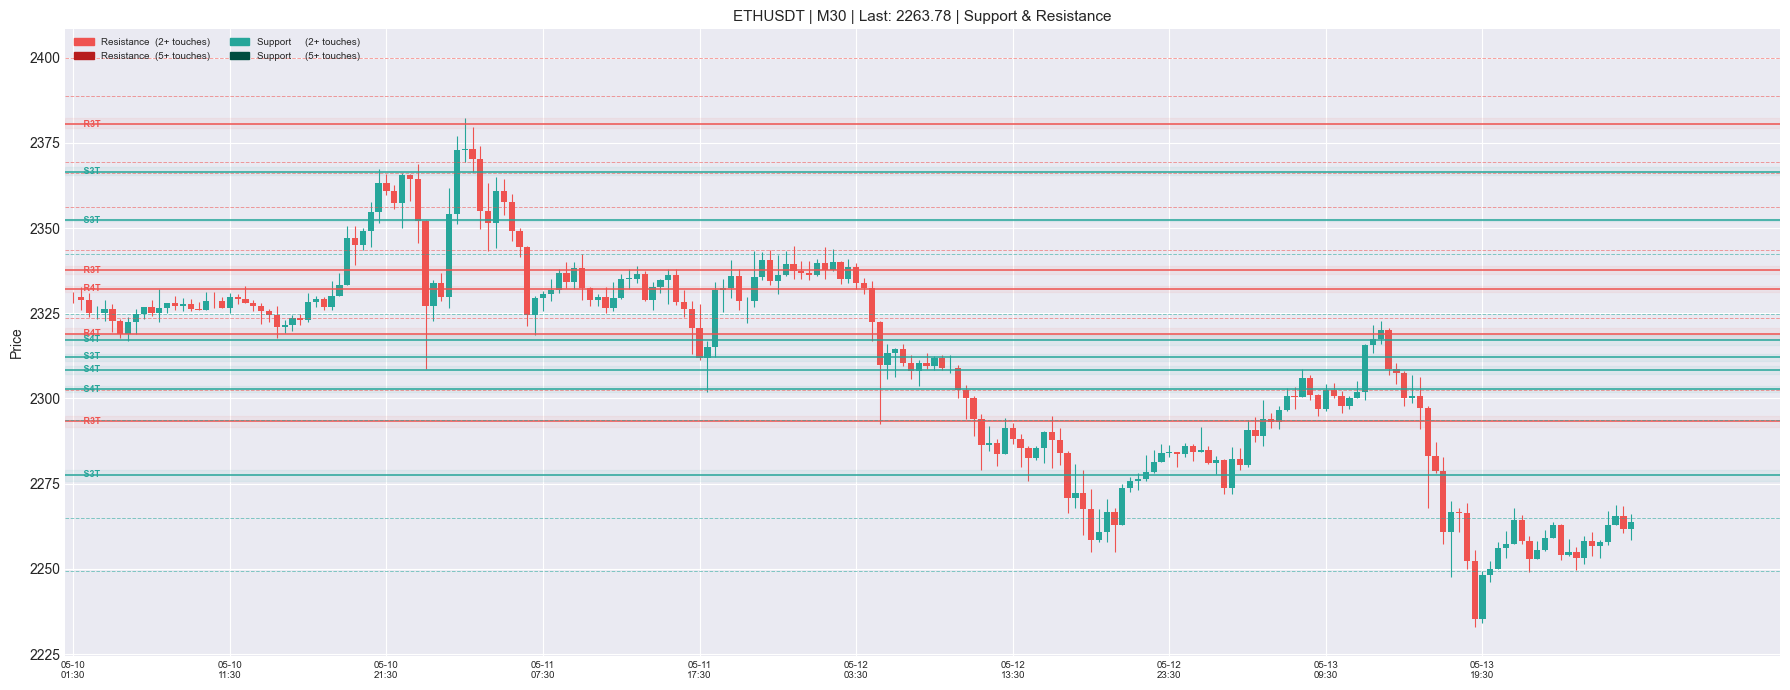


── H1 ── res=7 sup=10 (showing last 200 bars)


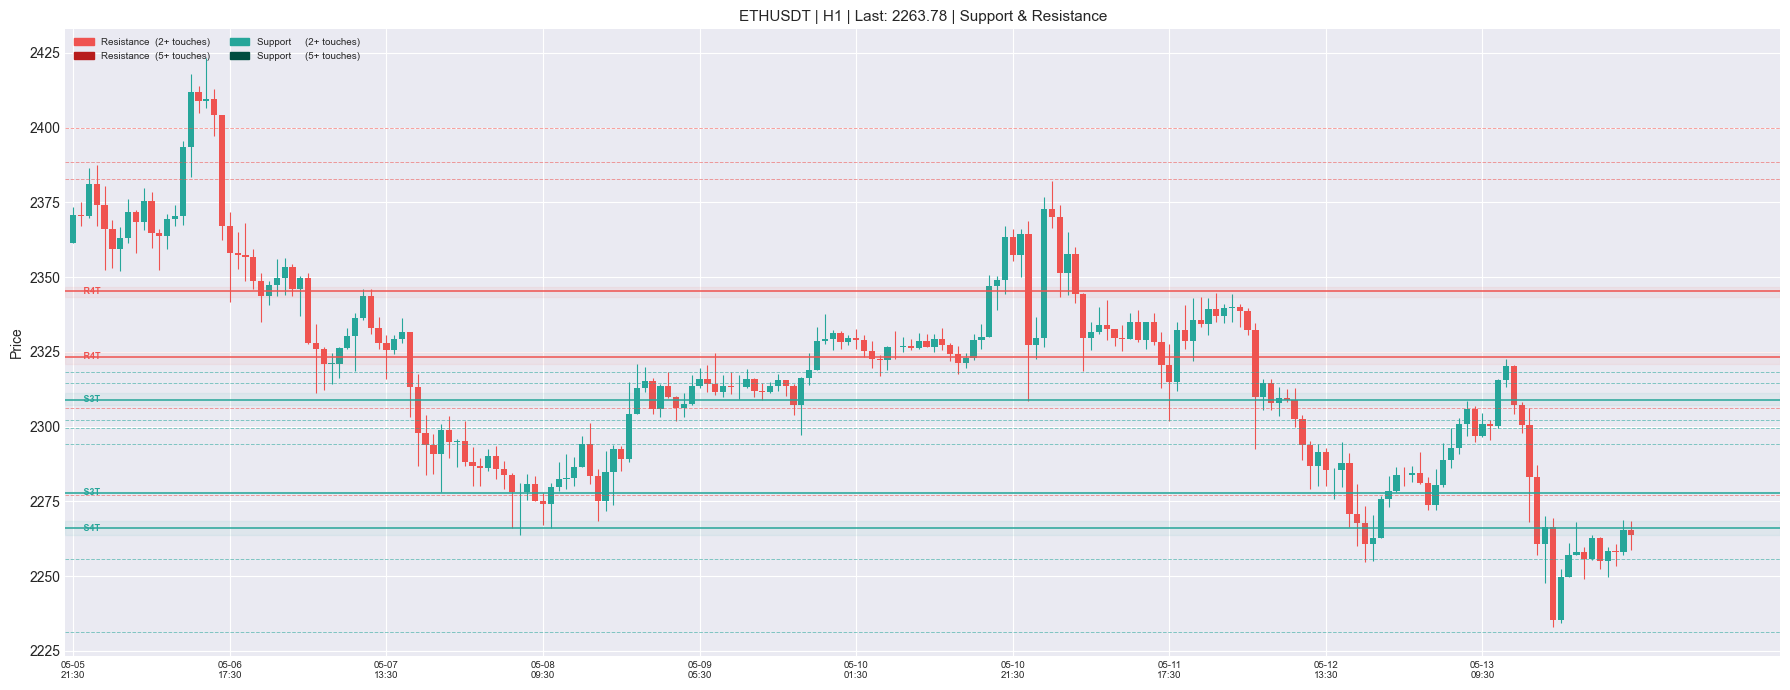


── H4 ── res=5 sup=5 (showing last 150 bars)


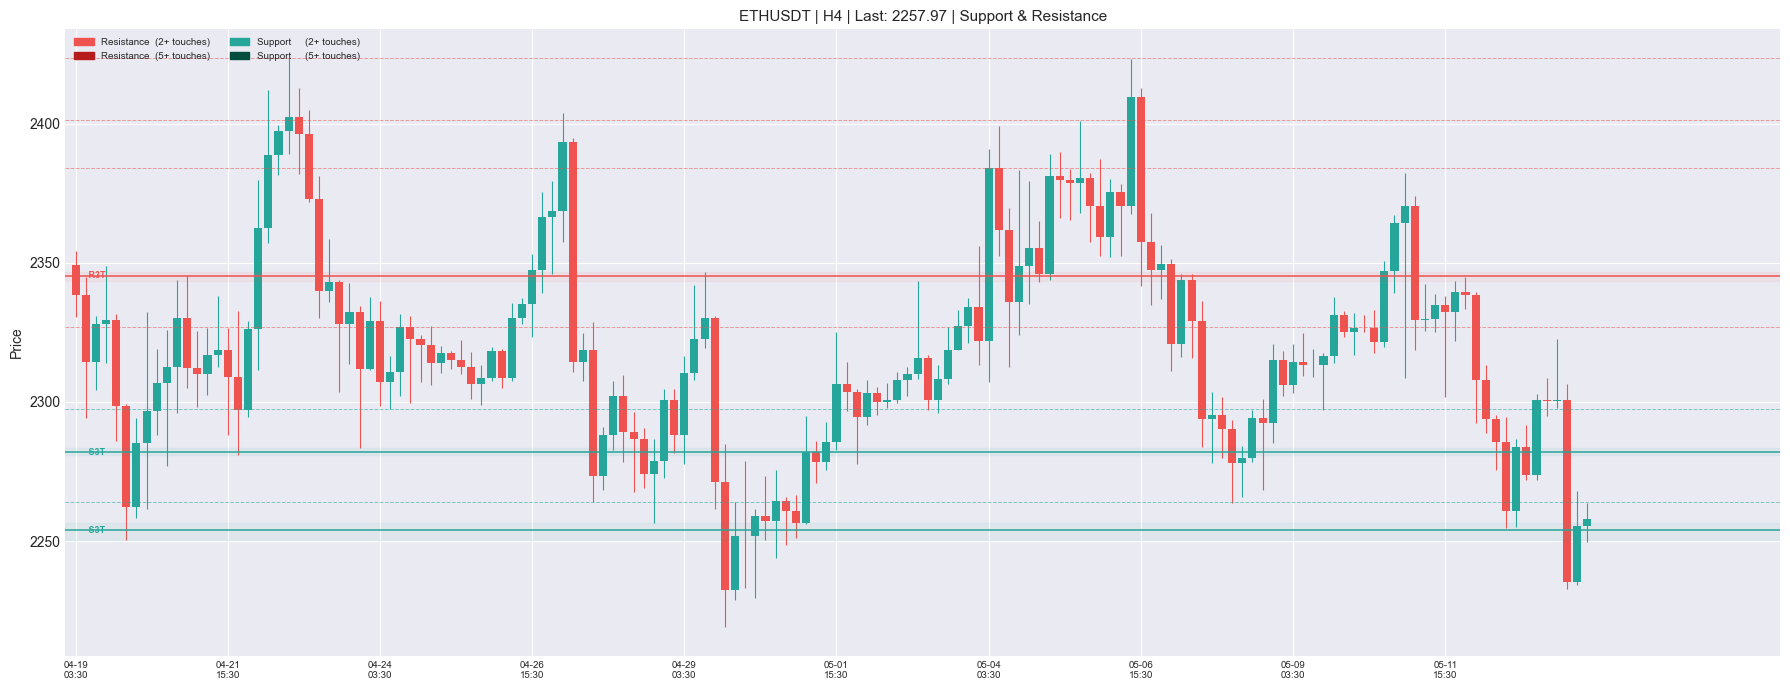


── D1 ── res=0 sup=0 (showing last 100 bars)


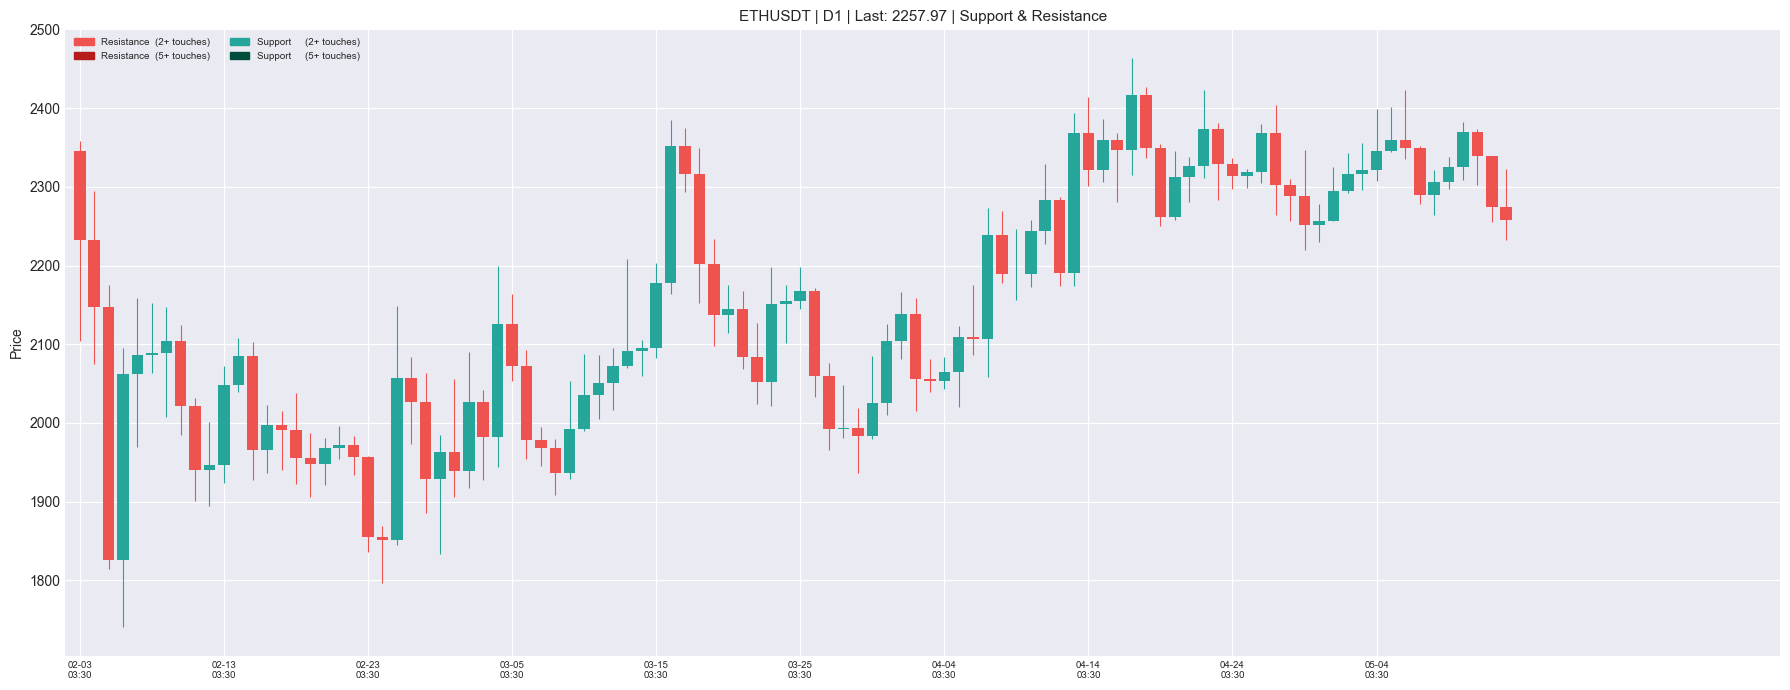

In [17]:
# SECTION 7 — Plot S/R for every available timeframe
for tf in available_tfs:
    if tf not in data or tf not in sr:
        continue
    df_tf = data[tf]
    res, sup = sr[tf]
    show = BARS_SHOW.get(tf, 200)
    print(f"\n── {tf} ── res={len(res)} sup={len(sup)} (showing last {show} bars)")
    plot_sr_chart(df_tf, tf, res, sup, show_n_bars=show)

---
## M5 Chart + H1 Strong Levels Overlay

چارت M5 با خطوط حمایت و مقاومت قوی تایم‌فریم H1 (نارنجی/آبی):

- **قرمز/سبز** → سطوح M5 خودی  
- **نارنجی** → مقاومت قوی H1  
- **آبی فیروزه‌ای** → حمایت قوی H1

M5 levels  — res: 25  sup: 29
H1 overlay — res: 2  sup: 3  (min 3 touches)


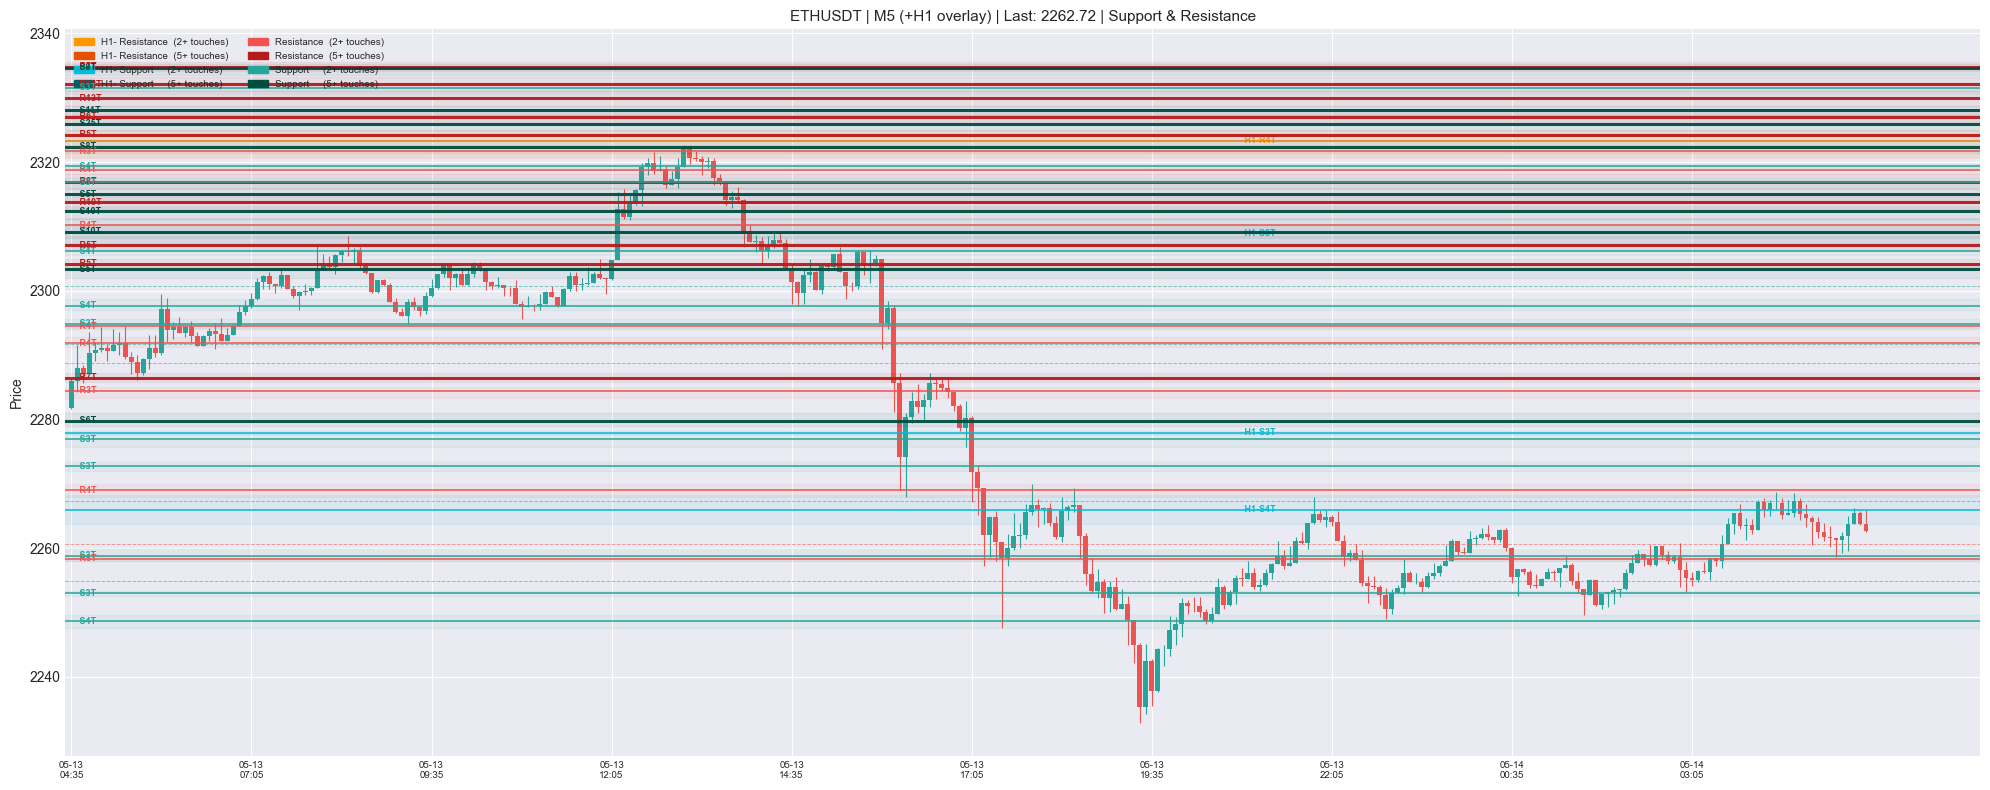

In [18]:
# SECTION 8 — M5 + H1 overlay
if "M5" not in data or "H1" not in data:
    print("M5 or H1 data not available — skipping overlay.")
else:
    df_m5 = data["M5"]
    res_m5, sup_m5 = sr["M5"]
    res_h1, sup_h1 = sr["H1"]

    # Filter H1 levels to overlay: only strong ones
    h1_res_overlay = [z for z in res_h1 if z["touches"] >= H1_OVERLAY_MIN]
    h1_sup_overlay = [z for z in sup_h1 if z["touches"] >= H1_OVERLAY_MIN]

    print(f"M5 levels  — res: {len(res_m5)}  sup: {len(sup_m5)}")
    print(f"H1 overlay — res: {len(h1_res_overlay)}  sup: {len(h1_sup_overlay)}"
          f"  (min {H1_OVERLAY_MIN} touches)")

    show = BARS_SHOW.get("M5", 300)
    plot_sr_chart(
        df_m5, "M5",
        res_m5, sup_m5,
        h1_res=h1_res_overlay,
        h1_sup=h1_sup_overlay,
        show_n_bars=show,
        figsize=(20, 8),
    )

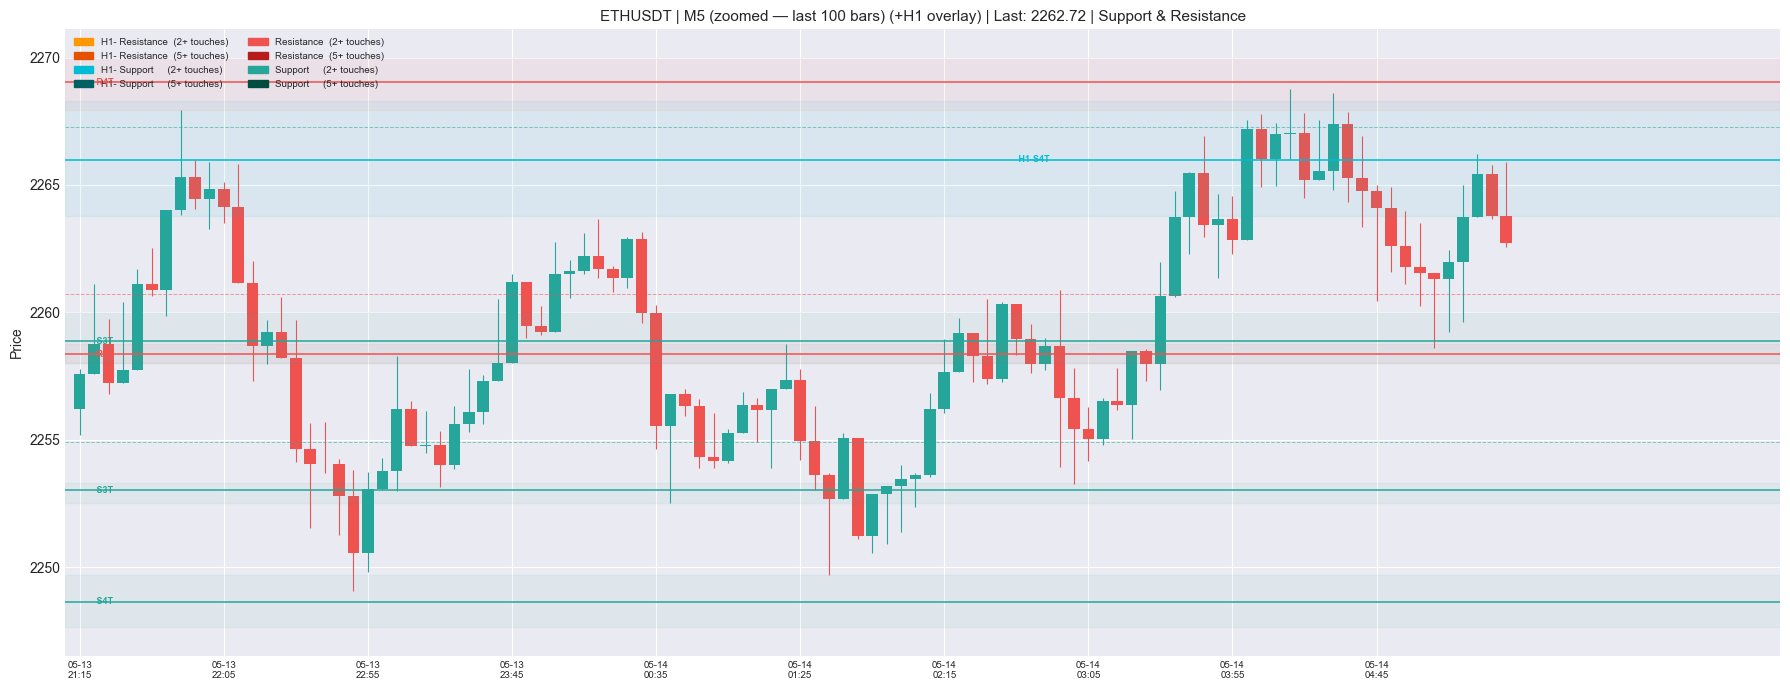

In [19]:
# SECTION 9 — Zoomed M5 view (last 100 bars) + H1 overlay
if "M5" in data and "H1" in data:
    df_m5 = data["M5"]
    res_m5, sup_m5 = sr["M5"]
    res_h1, sup_h1 = sr["H1"]

    h1_res_overlay = [z for z in res_h1 if z["touches"] >= H1_OVERLAY_MIN]
    h1_sup_overlay = [z for z in sup_h1 if z["touches"] >= H1_OVERLAY_MIN]

    plot_sr_chart(
        df_m5, "M5 (zoomed — last 100 bars)",
        res_m5, sup_m5,
        h1_res=h1_res_overlay,
        h1_sup=h1_sup_overlay,
        show_n_bars=100,
        figsize=(18, 7),
    )

In [20]:
# SECTION 10 — Export strong levels to CSV
from datetime import datetime

if not summary_df.empty:
    out_dir = _ROOT / "notebooks" / "results" / "sr_levels" / SYMBOL
    out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / f"sr_levels_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
    summary_df.to_csv(out_file, index=False)
    print(f"Saved: {out_file}")
    print(f"Total levels: {len(summary_df)} | Strong ({STRONG_TOUCHES}+): {len(strong_df)}")
else:
    print("Nothing to export.")

Saved: D:\bot\ema-h1trend-exchange\notebooks\results\sr_levels\ETHUSDT\sr_levels_20260514_2024.csv
Total levels: 143 | Strong (3+): 81
